In [ ]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#df = df[df['job_posted_date'].dt.year == 2025]
df['salary_year_avg'] = df['salary_year_avg'] * 0.75

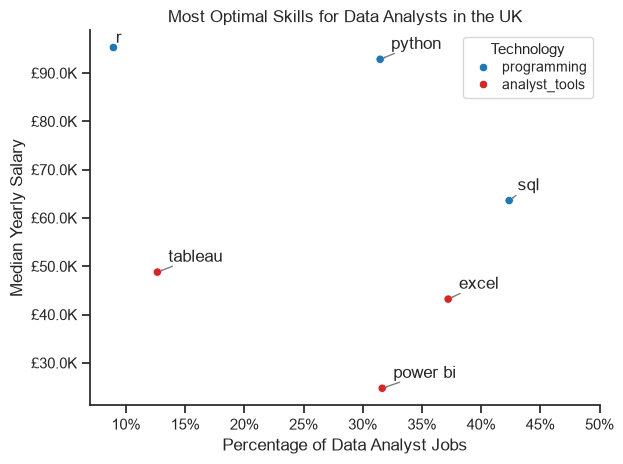

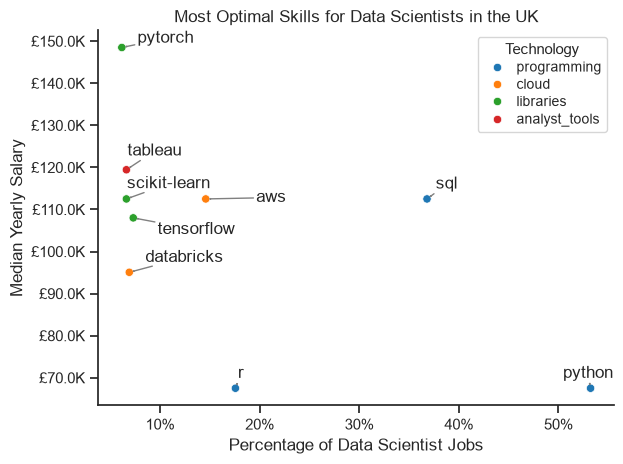

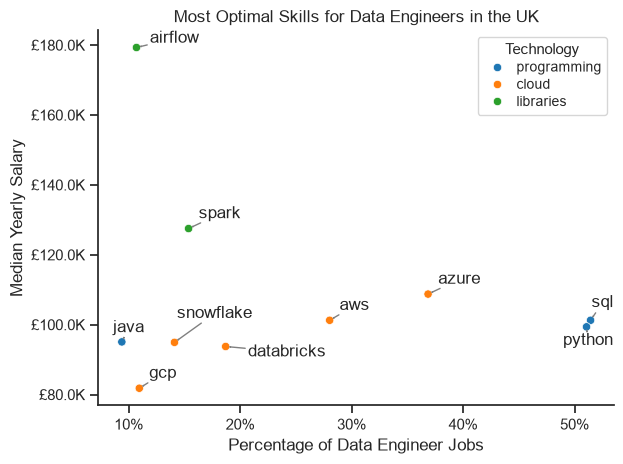

In [51]:
from matplotlib.ticker import PercentFormatter

#establishing list to iterate through and creating new columns for months and years of postings
job_list = ['Data Analyst', 'Data Scientist', 'Data Engineer']
#Convert to GBP

df_filtered = df[(df['job_title_short'].isin(job_list))&
            (df['job_country'] == 'United Kingdom')]


df_total_jobs = (
    df_filtered['job_title_short'].value_counts()
    .reset_index(name = 'total_jobs')
).head(3)

#List of dataframes for each separate job
df_jobs = [
    df[
        (df['job_title_short'] == job)
        & (df['job_country'] == 'United Kingdom')
    ]
    for job in job_list
]

#List of exploded dataframes for each separate job
df_jobs_exploded = [
    i.explode('job_skills').dropna(subset=['job_skills'])
    for i in df_jobs
]

df_salaries_exploded = [
    i.dropna(subset = ['salary_year_avg'])
    for i in df_jobs_exploded
]

#creates a series of the technologies, removes duplicates and NaN values
df_technology = (
    df_filtered['job_type_skills'].copy()
    .drop_duplicates()
    .dropna()
)

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

sns.set_theme(style = 'ticks')
for ((i, dframe_explode), (j, salary_frame), job) in zip((enumerate(df_jobs_exploded)), enumerate(df_salaries_exploded), job_list):
    df_skills = (
    dframe_explode.groupby(['job_title_short', 'job_skills']).size()
        .reset_index(name = 'skill_count')
    ).sort_values(by='skill_count', ascending = False)

    df_salaries = (
        salary_frame.groupby(['job_title_short', 'job_skills'])['salary_year_avg'].median()
         .reset_index(name = 'median_salary')
         .sort_values(by='median_salary', ascending = False)
    )
    
    df_skills_perc = (
        df_skills.merge(df_salaries, on=['job_title_short', 'job_skills'])
        .merge(df_total_jobs, on='job_title_short')
        .merge(df_technology, left_on='job_skills', right_on='skills')
)
    df_skills_perc['skill_perc'] = (df_skills_perc['skill_count'] / df_skills_perc['total_jobs'] )*100
    if i != 2:
        skill_limit = 6
    else:
        skill_limit = 8
    df_skills_high_demand = df_skills_perc[df_skills_perc['skill_perc'] > skill_limit]
    df_skills_high_demand = df_skills_high_demand.drop(columns = ['job_title_short'])
   
    sns.set_theme(style = 'ticks')
    palette = {
    'programming': '#1f77b4',
    'cloud': '#ff7f0e',
    'libraries': '#2ca02c',
    'analyst_tools': '#d62728'
}
    sns.scatterplot(data = df_skills_high_demand,
                    x = 'skill_perc',
                    y = 'median_salary',
                    hue = 'technology',
                    palette=palette)
    sns.despine()
    plt.xlabel(f'Percentage of {job} Jobs')
    plt.ylabel('Median Yearly Salary')
    plt.title(f'Most Optimal Skills for {job}s in the UK')
    if i == 0:
        plt.xlim(7,50)

    texts = []
    for _, row in df_skills_high_demand.iterrows():
        texts.append(
            plt.text(
                row['skill_perc'],
                row['median_salary'],
                row['job_skills']
            )
        )

    from adjustText import adjust_text
    # Adjust text to avoid overlap and add arrows
    adjust_text(
    texts,
    force_text=(1.5, 1.5),
    force_static=(1.5, 1.5),
    expand=(1.5, 1.5),
    arrowprops=dict(arrowstyle='->', color='gray')
)
    from matplotlib.ticker import PercentFormatter
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'£{(y/1000)}K'))
    ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
    plt.tight_layout()
    plt.legend(
    title="Technology",
    loc="upper right",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.4
)
    plt.show()





In [28]:
df_technology = df_filtered['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

df_technology

1268085                     {'programming': ['python', 'r']}
1268087    {'databases': ['postgresql'], 'other': ['kuber...
1268119                         {'analyst_tools': ['excel']}
1268150             {'analyst_tools': ['excel', 'power bi']}
1268301    {'cloud': ['azure', 'aws', 'gcp', 'redshift', ...
                                 ...                        
1777803    {'cloud': ['oracle', 'azure'], 'programming': ...
1778010    {'cloud': ['redshift', 'oracle', 'snowflake', ...
1779091    {'cloud': ['azure'], 'programming': ['sql', 'p...
1779662    {'cloud': ['snowflake', 'aws', 'azure', 'gcp',...
1780537    {'cloud': ['bigquery'], 'libraries': ['airflow...
Name: job_type_skills, Length: 7127, dtype: str

: 

: 